# Generate a spectrum with OpenWD

Choose a DA (hydrogen), DB (helium), DAB (homogeneous H/He), or DZ
(metal-polluted helium) model. This notebook uses the public **automatic
physics selection** entry point and always starts from scratch.

Edit the parameters below, run the cells in order, and inspect the saved
spectrum and plots. See the [user guide](../docs/getting-started.md) for
installation and the [limitations guide](../docs/limitations.md) before
interpreting a result scientifically. The saved outputs show a completed
12,000 K DA example; rerun the cells to calculate your own model.


## Setup

From the repository root, install with `python -m pip install -e .`,
then select that Python environment as this notebook's kernel. Use the current
checkout: older versions do not provide `run_model`.

Cool DB/DAB workflows require this source checkout, `QUALITY = "production"`
and log g = 8; unsupported requests fail explicitly, without changing your
parameters. Molecular DABs additionally require the checksum-pinned tables in
the [cool-model setup instructions](../research/cool_models/README.md#additional-molecular-dab-data).
No table is downloaded by this notebook and no previous atmosphere is used.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
from uuid import uuid4
import json
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

repo = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src/wd_spectra/__init__.py").is_file()),
    None,
)
if repo is not None:
    if "wd_spectra" in sys.modules:
        loaded = Path(sys.modules["wd_spectra"].__file__).resolve()
        if repo.resolve() not in loaded.parents:
            raise RuntimeError("Restart the kernel to use this checkout.")
    sys.path.insert(0, str(repo / "src"))

import wd_spectra
from wd_spectra import DAConfig, DABConfig, DBConfig, DZConfig, run_model
from wd_spectra.constants import STEFAN_BOLTZMANN
from wd_spectra.radiative_transfer import compiled_backend_available

plt.rcParams.update({
    "figure.dpi": 120, "axes.labelsize": 14, "axes.titlesize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "lines.linewidth": 1.8,
})
print(f"OpenWD {wd_spectra.__version__} from {wd_spectra.__file__}")
print(f"Compiled transfer backend: {compiled_backend_available()}")


Matplotlib is building the font cache; this may take a moment.


OpenWD 0.1.3 from /private/tmp/openwd-pr2-edit.i3NFbk/worktree/src/wd_spectra/__init__.py
Compiled transfer backend: True


## Choose a model

`MODEL` may be `"DA"`, `"DB"`, `"DAB"` or `"DZ"`.
`standard` is useful for the warm example below;
use `production` for the qualified cool DB/DAB workflows.
`quick` only tests the interface and generally does not converge.

`REQUIRE_CONVERGENCE = False` retains and plots exploratory results with a
warning. Set it to `True` to stop if numerical qualification fails; diagnostic
files are still retained. Physics/data/execution errors always stop the run,
rather than selecting a different model.


In [2]:
MODEL = "DA"
TEFF = 12_000.0   # K
LOGG = 8.0
QUALITY = "standard"

LOG_H_TO_HE = -2.0       # used only for DAB
DZ_ABUNDANCES = None     # None uses the bundled GD 40 composition
REQUIRE_CONVERGENCE = False
RESEARCH_DATA = None     # optional Path to the pinned molecular tables
SAVE_FIGURE = False
OUTPUT_ROOT = Path("results") / "example"


## Build the request

In [3]:
MODEL = MODEL.upper()
common = dict(effective_temperature=TEFF, logg=LOGG, quality=QUALITY)
if MODEL == "DA":
    config = DAConfig(**common)
elif MODEL == "DB":
    config = DBConfig(**common)
elif MODEL == "DAB":
    config = DABConfig(log_hydrogen_to_helium=LOG_H_TO_HE, **common)
elif MODEL == "DZ":
    dz_options = {} if DZ_ABUNDANCES is None else {"abundances": DZ_ABUNDANCES}
    config = DZConfig(**common, **dz_options)
else:
    raise ValueError("MODEL must be 'DA', 'DB', 'DAB', or 'DZ'")

ZOOM_WINDOWS = {
    "DA": (3_800.0, 7_000.0), "DB": (3_800.0, 7_000.0),
    "DAB": (3_800.0, 7_000.0), "DZ": (2_600.0, 5_500.0),
}
zoom_lower, zoom_upper = ZOOM_WINDOWS[MODEL]
print(config)
print("Physics and the native output wavelength grid are selected by run_model.")


DAConfig(effective_temperature=12000.0, logg=8.0, quality='standard', lyman_profile_source='allard', allard_minimum_effective_temperature=9000.0, include_molecules=None, h3plus_partition_model='neale-tennyson-1995', mixing_length_alpha=0.7, use_cool_mean_3d_temperature_differential=False, balmer_self_broadening_prescription=None, balmer_self_broadening_truncation_closure='stark-core', atmosphere_solver='adaptive-newton', multigrid_initialization=False)
Physics and the native output wavelength grid are selected by run_model.


## Calculate the atmosphere and spectrum

This can take minutes or longer for cool or strongly polluted models.
`run_model` reports its selected physics and progress while it works.

Every execution creates a unique output directory. The numerical spectrum,
request, diagnostics and provenance are saved automatically, even when
`SAVE_FIGURE` is false. No saved model is passed back into the solver.
If a run fails, diagnose the reported error; do not replace the selected physics.

The saved output illustrates one completed run. Rerun the cells after
changing the parameters or updating the code.


In [4]:
# Clear the previous interactive result before starting, including on failure.
run = None
spectrum = None
manifest = None
summary = None
started = time.perf_counter()
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
output_directory = (
    OUTPUT_ROOT / f"{MODEL.lower()}-{TEFF:g}K-{stamp}-{uuid4().hex[:8]}"
)
print(f"Starting fresh {MODEL} ({QUALITY}); outputs: {output_directory}", flush=True)
run = run_model(
    config,
    output_directory,
    research_data=RESEARCH_DATA,
    require_convergence=REQUIRE_CONVERGENCE,
)
print(f"Finished in {(time.perf_counter() - started) / 60:.2f} min")


Starting fresh DA (standard); outputs: results/example/da-12000K-20260907T211013Z-df5ccf69


OpenWD: constructing the provisional material screen (not a converged atmosphere)


OpenWD physics selection: da: Established hydrogen EOS/opacity policy


{"diagnostics": {}, "experimental": false, "reason": "Established hydrogen EOS/opacity policy", "tested_point": false, "workflow": "da"}


{"iteration": 1, "flux": 0.7157649076239168, "correction": 0.04000000000000004}


...

{"iteration": 44, "flux": 4.4800545850876006e-07, "correction": 0.004597491397592982}


{"iteration": 45, "flux": 6.52799364231349e-07, "correction": 0.0009564613358295572}


{"iteration": 46, "flux": 8.886881341929609e-09, "correction": 0.0003825155465921881}


{"iteration": 47, "flux": 8.886881341929609e-09, "correction": 5.4619047418214e-07}


Finished in 2.22 min


## Check numerical qualification

The public run's qualification flag is authoritative: atomic models use the
five-gate atmosphere certificate, while experimental dense/molecular workers
use their dedicated checkers. We do not reconstruct a cool atmosphere with an
incompatible EOS just to inspect it.

Finite, positive arrays are only **basic data checks**, not evidence of
equilibrium. The spectrum integral below covers only the returned wavelength
interval; it is not a bolometric convergence test. In particular, the retained
atomic spectrum method has [known transfer-consistency limits](../docs/limitations.md#spectrum-accuracy-and-reference-comparisons).


In [5]:
if run is None:
    raise RuntimeError("No successful run is available; inspect the calculation error above.")

spectrum = run.spectrum
manifest = json.loads((run.output_directory / "model-run.json").read_text())
qualified = run.convergence_verified
if manifest.get("status") != "completed" or manifest.get("convergence_verified") is not qualified:
    raise RuntimeError("Run manifest and numerical qualification disagree.")
if manifest.get("cold_start") is not True or manifest.get("initial_checkpoint") is not None:
    raise RuntimeError("This notebook requires a recorded cold start.")

wave = spectrum.wavelength_angstrom
flux = spectrum.surface_flux_lambda
assert wave.ndim == 1 and len(wave) >= 2
assert np.all(np.isfinite(wave)) and np.all(wave > 0) and np.all(np.diff(wave) > 0)
assert flux.shape == wave.shape and np.all(np.isfinite(flux))
assert np.all(flux >= 0) and np.any(flux > 0)
integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
sampled_flux_ratio = integrate(flux, wave) / (STEFAN_BOLTZMANN * config.effective_temperature**4)
summary = {
    "workflow": run.selection.workflow,
    "qualification_verified": qualified,
    "cold_start": manifest["cold_start"],
    "wavelength_min_angstrom": float(wave[0]),
    "wavelength_max_angstrom": float(wave[-1]),
    "sampled_flux_ratio": float(sampled_flux_ratio),
}
print(f"Selected physics: {run.selection.workflow}: {run.selection.reason}")
print("Numerical qualification:", "verified for declared equations" if qualified else "UNQUALIFIED / exploratory")
print(f"Spectrum: {run.spectrum_path}")
print(f"Diagnostics and provenance: {run.output_directory}")
print(f"Sampled {wave[0]:g}–{wave[-1]:g} Angstrom flux ratio: {sampled_flux_ratio:.4f}")
print("Basic data checks: passed (not an equilibrium certificate)")

if not run.selection.experimental:
    details = json.loads((run.output_directory / "metadata.json").read_text())
    certificate = details.get("atmosphere_metadata", {}).get("equilibrium_certificate")
    print("Atmosphere certificate:")
    print(json.dumps(certificate, indent=2) if certificate is not None else "Not available")
else:
    print("Qualification is from the dedicated worker checker; detailed records are in worker/.")

if not qualified:
    warnings.warn("UNQUALIFIED: exploratory spectrum only; diagnose convergence before scientific use.", RuntimeWarning)


Selected physics: da: Established hydrogen EOS/opacity policy
Numerical qualification: verified for declared equations
Spectrum: /private/tmp/openwd-pr2-edit.i3NFbk/worktree/examples/results/example/da-12000K-20260907T211013Z-df5ccf69/spectrum.txt
Diagnostics and provenance: /private/tmp/openwd-pr2-edit.i3NFbk/worktree/examples/results/example/da-12000K-20260907T211013Z-df5ccf69
Sampled 900–30000 Angstrom flux ratio: 0.9774
Basic data checks: passed (not an equilibrium certificate)
Atmosphere certificate:
{
  "schema": 1,
  "scope": "declared equations on the structure grid",
  "verified": true,
  "checks": {
    "all_depth_flux": {
      "value": 8.886881341929609e-09,
      "tolerance": 0.002,
      "passed": true,
      "measured": true
    },
    "local_energy": {
      "value": 1.7915108685569283e-06,
      "tolerance": 0.002,
      "passed": true,
      "measured": true
    },
    "temperature_stationarity": {
      "value": 5.4619047418214e-07,
      "tolerance": 0.0002,
      "

## Plot the spectrum

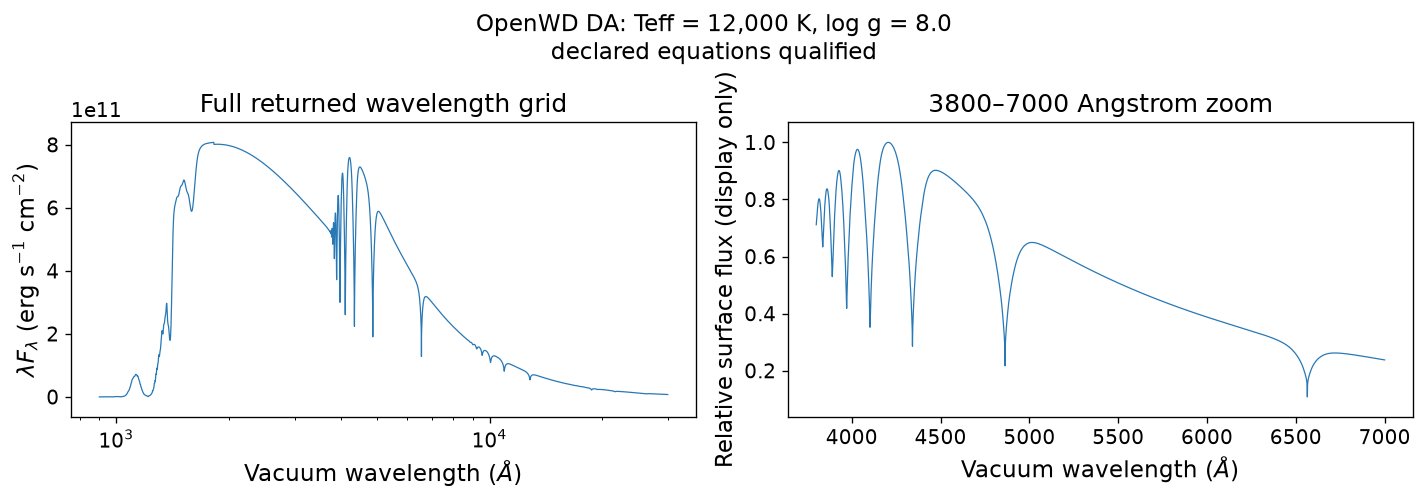

In [6]:
if run is None or spectrum is None or summary is None:
    raise RuntimeError("Run the calculation and qualification cells successfully before plotting.")
wave = spectrum.wavelength_angstrom
flux = spectrum.surface_flux_lambda
zoom = (wave >= zoom_lower) & (wave <= zoom_upper)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(wave, wave * flux, color="#2878B5", linewidth=0.75)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"Vacuum wavelength ($\AA$)")
axes[0].set_ylabel(r"$\lambda F_\lambda$ (erg s$^{-1}$ cm$^{-2}$)")
axes[0].set_title("Full returned wavelength grid")
axes[0].margins(y=0.08)

if np.any(zoom) and np.max(flux[zoom]) > 0:
    axes[1].plot(wave[zoom], flux[zoom] / np.max(flux[zoom]), color="#2878B5", linewidth=0.75)
else:
    axes[1].text(0.5, 0.5, "No positive flux in this zoom", ha="center", transform=axes[1].transAxes)
axes[1].set_xlabel(r"Vacuum wavelength ($\AA$)")
axes[1].set_ylabel("Relative surface flux (display only)")
axes[1].set_title(f"{zoom_lower:g}–{zoom_upper:g} Angstrom zoom")
axes[1].margins(y=0.08)
status_label = "declared equations qualified" if run.convergence_verified else "UNQUALIFIED / exploratory"
fig.suptitle(f"OpenWD {MODEL}: Teff = {TEFF:,.0f} K, log g = {LOGG:.1f}\n{status_label}", fontsize=14)
fig.tight_layout()

if SAVE_FIGURE:
    figure_base = run.output_directory / f"openwd_{MODEL.lower()}_example_spectrum"
    fig.savefig(figure_base.with_suffix(".png"), dpi=220, bbox_inches="tight")
    fig.savefig(figure_base.with_suffix(".pdf"), bbox_inches="tight")
    print(f"Saved {figure_base.with_suffix('.png')} and .pdf")
plt.show()


## Try another WD

Change the controls, then rerun from that cell downward. Each run stays
independent; previous results are neither overwritten nor used as inputs.
These examples are starting points, not validation over arbitrary gravity,
abundance or temperature ranges. See the [tested points](../docs/tested-temperature-ranges.md).


In [7]:
# Warm examples:
# MODEL, TEFF, LOGG, QUALITY = "DB", 22_000.0, 8.0, "production"
# MODEL, TEFF, LOGG, QUALITY = "DAB", 20_000.0, 8.0, "production"
# MODEL, TEFF, LOGG, QUALITY = "DZ", 15_300.0, 8.0, "production"
# DZ_ABUNDANCES = {"O": -5.61, "Mg": -6.24, "Ca": -6.88}

# Qualified cool-workflow examples at the documented composition:
# MODEL, TEFF, LOGG, QUALITY = "DB", 8_000.0, 8.0, "production"
# MODEL, TEFF, LOGG, QUALITY = "DAB", 7_500.0, 8.0, "production"
# LOG_H_TO_HE = -2.0
# RESEARCH_DATA = Path("/path/to/pinned-molecular-tables")
